## Partial Differentiation

In [30]:
import numpy as np
import matplotlib.pyplot as plt

One of the most important ideas in physics is taking the gradient. For a conservative field: $$\vec{F} = -\nabla U $$
For now, let's plot a function of two variables:
$$U(x,y) = \frac{1}{2}k_xx^2 + \frac{1}{2}k_yy^2 + \alpha xy $$

In [31]:
kx = 2.0
ky = 4.0
alpha = 1.0

def U(x, y):  #def allows us to define a funcion in python.
   return 0.5*kx*x**2 + 0.5*ky*y**2 + alpha*x*y

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

X, Y = np.meshgrid(x, y)  #meshgrid here creates a

##Z = 0.5*kx*X**2 + 0.5*ky*Y**2 + alpha*X*Y  ---> if you choose to not use def U(x,y)
Z = U(X,Y)

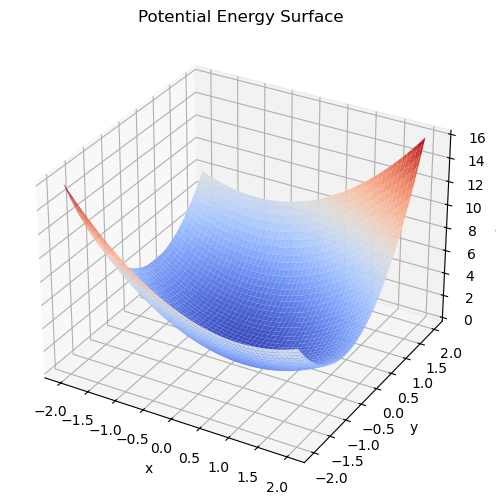

In [32]:
#plotting 3d
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")  #makes it 3D

ax.plot_surface(X, Y, Z, cmap='coolwarm') #many different cmap colors you can play with

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("U(x,y)")
ax.set_title("Potential Energy Surface")

plt.show()

## Countour Plots

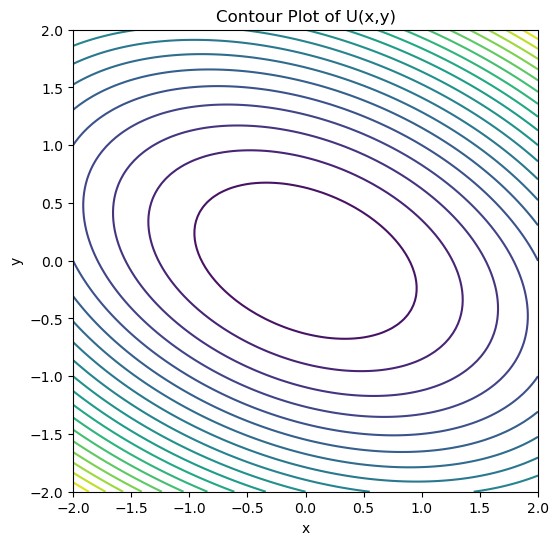

In [33]:
plt.figure(figsize=(6, 6))

plt.contour(X, Y, Z, levels=20)  

plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour Plot of U(x,y)")

plt.show()

## Partial Derivatives
$$U(x,y) = \frac{1}{2}k_xx^2 + \frac{1}{2}k_yy^2 + \alpha xy $$
$$\frac{\partial U}{\partial x} = k_xx + \alpha y $$

$$\frac{\partial U}{\partial y} = k_y y^2 + \alpha x $$
so,
$$\nabla U = \frac{\partial U}{\partial x}\hat x + \frac{\partial U}{\partial y}\hat y $$
Let's define these functions in python

In [34]:
#defining functions helps keep a lot of code clearer in my opinion
def dU_dx(x, y):
    return kx*x + alpha*y

def dU_dy(x, y):
    return ky*y + alpha*x

To evaluate the gradient at a point:

In [35]:
x0 = 1.0
y0 = 0.5

grad_U = np.array([dU_dx(x0, y0), dU_dy(x0, y0)])

print("Gradient at point:", grad_U)

Gradient at point: [2.5 3. ]


Plotting the gradient:

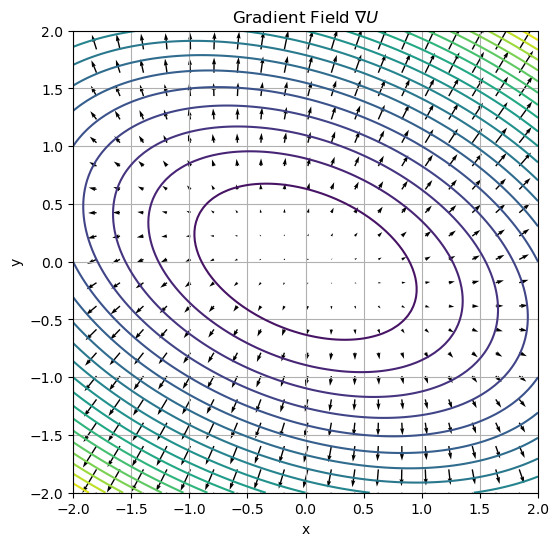

In [36]:
dUdx = dU_dx(X, Y)
dUdy = dU_dy(X, Y)

plt.figure(figsize=(6, 6))

plt.contour(X, Y, Z, levels=20)
plt.quiver(X[::5, ::5], Y[::5, ::5],  #plots the arrows. 
           dUdx[::5, ::5], dUdy[::5, ::5])  #:: using both rows of the array.
                                            #so it takes data every 5th element of both
                                            #rows and columns

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Gradient Field $\nabla U$")
plt.grid()

plt.show()

## Force
When the field is conservative,  $$\vec{F} = -\nabla U $$
then, $$F_x = - \frac{\partial U}{\partial x}$$
and, $$F_y = - \frac{\partial U}{\partial y}$$

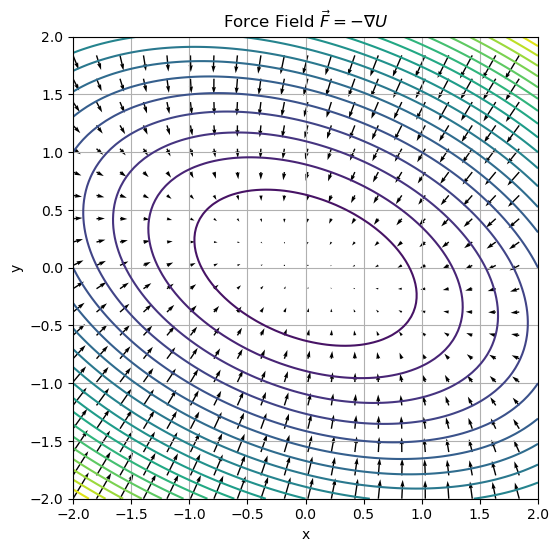

In [37]:
#same code as above with difference being the negative sign
Fx = -dUdx
Fy = -dUdy

plt.figure(figsize=(6, 6))

plt.contour(X, Y, Z, levels=20)
plt.quiver(X[::5, ::5], Y[::5, ::5],
           Fx[::5, ::5], Fy[::5, ::5])

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Force Field $\vec{F} = -\nabla U$")
plt.grid()

plt.show()

## Numerical Derivatives
Derivatives can be approximated using the the method of finite differences. As always let's do a taylor expansion at some point $x_0$ with some forward step h. 
$$f(x_0 + h) = f(x_0) + \frac{f'{(x_0)}}{1!}h + \frac{f^{(2)}(x_0)}{2!}h^2 + \cdots + \frac{f^{(n)}(x_0)}{n!}h^n + R_n(x) $$
We can get rid of most of these terms and still maintain enough accuracy, so from truncating the series:
$$f(x_0 + h) = f(x_0) + f'(x_0)h + R_1(x) $$
We can also assume $R_1(x)$ is sufficiently small so wer'es left with:
$$f(x_0 + h) = f(x_0) + f'(x_0)h $$
From here we simply solve for $f'(x_0)$ which gives the forward difference method:
$$\boxed{f'(x_0) \approx \frac{f(x_0 + h) - f(x_0)}{h}} $$

Notice how this essentially looks like the limit definition of the derivative: 
$$f'(x_0) = \lim_{h \to 0} \frac{f(x_0 + h) - f(x_0)}{h}$$
I want to apply the same logic you would use in the limit definition to the numerical version. As h tends to zero you get the derivative or in computational terms, the smaller your step size h, the more accurate the value of your derivative becomes.

There are different finite difference methods such as forward difference, backward difference, and central difference. 

We will be using the central one since it tends to be more accurate than the others: 
$$\frac{dF}{dx}  = \frac{F(x+h) - F(x-h)}{2h}$$

A quick note on the central difference method. Only use it for smooth, continous functions.

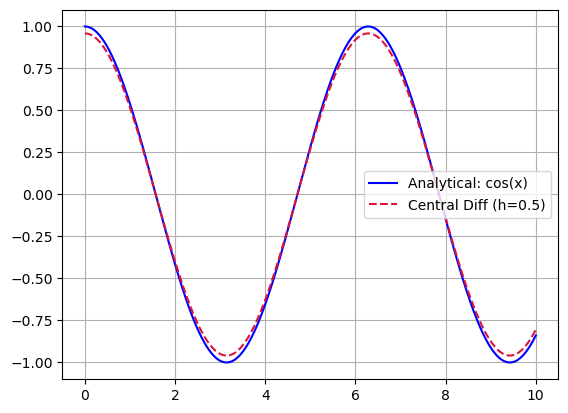

In [38]:
#Define your funcition
def my_function(x):
    return np.sin(x)
    
#defining numerical deriative
def numerical_derivative(f, x, h):
    return (f(x+h) - f(x-h)) / (2*h)

x = np.linspace(0, 10, 1000)
df = numerical_derivative(my_function, x, h=0.5)  #smaller h means more accuracy

plt.plot(x, np.cos(x), label='Analytical: cos(x)', color='blue')
plt.plot(x, df, '--', label='Central Diff (h=0.5)', color='crimson')
plt.legend()
plt.grid(True)
plt.show()



We can expand this finite difference method to partial derivatives.

The x partial deritavie can be approximated as: 
$$\frac{\partial U}{\partial x}  = \frac{U(x+h,y) - U(x-h, y)}{2h}$$
where h is the step size. For the y partial: 
$$\frac{\partial U}{\partial y}  = \frac{U(x,y+h) - U(x, y-h)}{2h}$$

In [39]:
def numerical_dU_dx(x, y, h=1e-5): #the smaller the h, the more accurate
    return (U(x+h, y) - U(x-h, y)) / (2*h)

def numerical_dU_dy(x, y, h=1e-5):
    return (U(x, y+h) - U(x, y-h)) / (2*h)

In [40]:
x0 = 1.0
y0 = 0.5

print("Analytical dU/dx:", dU_dx(x0, y0))
print("Numerical dU/dx:", numerical_dU_dx(x0, y0))

print("Analytical dU/dy:", dU_dy(x0, y0))
print("Numerical dU/dy:", numerical_dU_dy(x0, y0))

Analytical dU/dx: 2.5
Numerical dU/dx: 2.4999999999941735
Analytical dU/dy: 3.0
Numerical dU/dy: 2.9999999999974487


In [41]:
x0 = 1.0
y0 = 0.5

grad = np.array([dU_dx(x0, y0), dU_dy(x0, y0)])

print("Gradient:", grad)

Gradient: [2.5 3. ]


In [42]:
n = np.array([1, 1])
n = n / np.linalg.norm(n)

directional_derivative = grad @ n

print("Directional derivative:", directional_derivative)

Directional derivative: 3.889087296526011


# Step-size Dependence
Numerical derivative depend on the step size h. When h is too large, you get less accuracy. When h is too small, round off errors can accumalate.

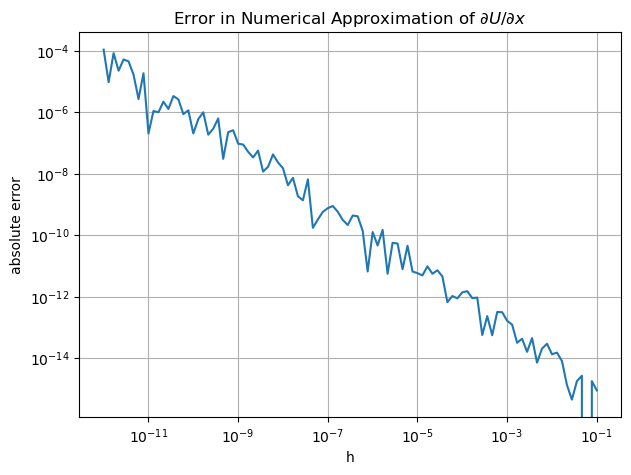

In [43]:
x0 = 1.0
y0 = 0.5

h_values = np.logspace(-12, -1, 100)  #evenspaced array on a logrithm scale

exact = dU_dx(x0, y0)

errors = []

for h in h_values:
    approx = numerical_dU_dx(x0, y0, h)
    error = abs(approx - exact)
    errors.append(error)

plt.figure(figsize=(7, 5))

plt.loglog(h_values, errors)

plt.xlabel("h")
plt.ylabel("absolute error")
plt.title(r"Error in Numerical Approximation of $\partial U/\partial x$")
plt.grid(True)

plt.show()

# Directional Derivative

The gradient tells us how the function changes in any direction.

The directional derivative of U in the direction of a unit vector 
n
^
 is:

D
n
^
	

U=∇U⋅
n
^
.

Let’s choose the point:
(x0,y0)=(1,0.5).

In [44]:
x0 = 1.0
y0 = 0.5

grad = np.array([dU_dx(x0, y0), dU_dy(x0, y0)])

print("Gradient:", grad)

Gradient: [2.5 3. ]


Direction: $$\hat{n} = \frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 1  \end{bmatrix} $$

In [45]:
n = np.array([1, 1])
n = n / np.linalg.norm(n)

directional_derivative = grad @ n

print("Directional derivative:", directional_derivative)

Directional derivative: 3.889087296526011


# Equilibrium Points
Equilibrium points occurs when the force is zero: $\vec{F} = -\nabla U= 0 $, so we need 
$$\frac{\partial U}{\partial x}=0 $$, $$\frac{\partial U}{\partial x} = 0$$
Taking the partial derivatives from our potential:
$$k_x + \alpha y = 0$$, $$\alpha x + k_y y = 0 $$
This is a simple linear system.

In [46]:
A = np.array([[kx, alpha],
              [alpha, ky]])

b = np.array([0, 0])

equilibrium = np.linalg.solve(A, b)

print("Equilibrium point:", equilibrium)

Equilibrium point: [0. 0.]


# Optional Problems
1. Plot the surface, contour plot, gradient field, and force field for $$U(x,y) = x^4 - x^2 =y^2 $$.
2. Let $T(x,y) = 100e^{-(x^2 + y^2)} $ Plot T(x,y) and it's gradient